# Bulgarian beaches × Copernicus Marine — exploratory notebook

Goal: for each Bulgarian seaside bathing water (from EEA), pull biogeochemistry indicators from the **Black Sea BGC analysis & forecast** product and compute simple stats.

Run cells top-to-bottom. Each step is independent so you can poke at intermediate results.

## Prereqs
```bash
pip install copernicusmarine xarray netcdf4 pandas matplotlib requests
copernicusmarine login   # one-time, free account at https://data.marine.copernicus.eu/register
```


In [ ]:
!pip install copernicusmarine xarray netcdf4 pandas matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into

In [ ]:
!copernicusmarine login   # one-time, free account at https://data.marine.copernicus.eu/register

INFO - 2026-04-25T14:59:48Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
Copernicus Marine username: mr.greend233@gmail.com
Copernicus Marine password: 
INFO - 2026-04-25T15:01:59Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.


In [ ]:
import requests
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import copernicusmarine as cm
from datetime import datetime, timedelta

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

## Step 1 — Pull all Bulgarian coastal bathing waters from EEA

In [ ]:
EEA_URL = (
    'https://water.discomap.eea.europa.eu/arcgis/rest/services'
    '/BathingWater/BathingWater_Dyna_WM/MapServer/0/query'
)

params = {
    'where': "countryCode='BG' AND bwWaterCategory='Coastal'",
    'outFields': 'bathingWaterIdentifier,bathingWaterName,longitude,latitude,qualityStatus',
    'returnGeometry': 'false',
    'f': 'json',
}

resp = requests.get(EEA_URL, params=params, timeout=20)
resp.raise_for_status()
raw = resp.json()

beaches = pd.DataFrame([f['attributes'] for f in raw['features']])
beaches = beaches.rename(columns={
    'bathingWaterIdentifier': 'id',
    'bathingWaterName': 'name',
    'longitude': 'lon',
    'latitude': 'lat',
    'qualityStatus': 'eea_quality',
})
print(f'beaches: {len(beaches)}')
beaches.head()

beaches: 92


,id,name,lon,lat,eea_quality
0,BG3310104426003018,КАМЧИЯ-ПЛАЖ РОМАНТИКА,27.8889,43.0392,Excellent
1,BG3310507598003022,БЯЛА-ПЛАЖ ЧАЙКА,27.8981,42.8542,Excellent
2,BG3310610135003006,СВ.СВ. КОНСТАНТИН И ЕЛЕНА-ГОЛЯМ ПЛАЖ,28.0153,43.2325,Excellent
3,BG3310610135003016,ХИЖА ЧЕРНОМОРЕЦ,27.9286,43.1186,Excellent
4,BG3320302508008016,БАЛЧИК-ДВОРЕЦА,28.1464,43.4028,Excellent


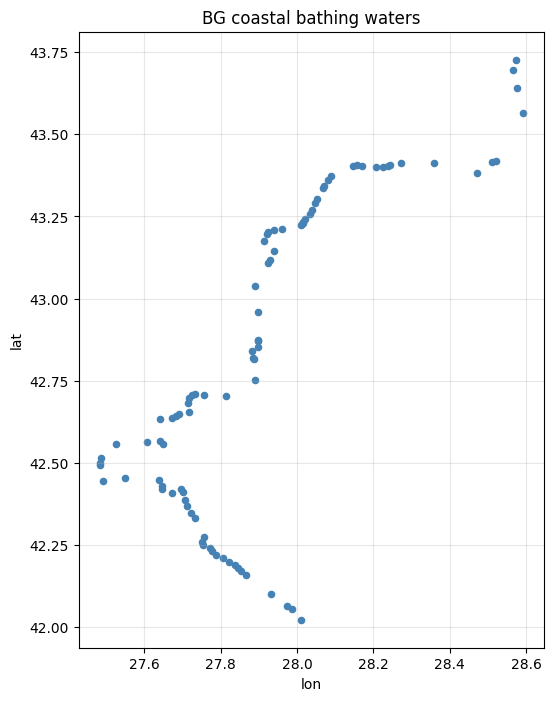

bbox: {'min_lon': 27.4333, 'max_lon': 28.6403, 'min_lat': 41.9733, 'max_lat': 43.7767}


In [ ]:
# Quick map sanity check
fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(beaches['lon'], beaches['lat'], s=20, c='steelblue')
ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.set_title('BG coastal bathing waters')
ax.grid(alpha=0.3)
plt.show()

BG_BBOX = {
    'min_lon': float(beaches['lon'].min()) - 0.05,
    'max_lon': float(beaches['lon'].max()) + 0.05,
    'min_lat': float(beaches['lat'].min()) - 0.05,
    'max_lat': float(beaches['lat'].max()) + 0.05,
}
print('bbox:', BG_BBOX)

## Step 2 — Discover the right Copernicus dataset IDs

Dataset IDs change occasionally. Use `cm.describe()` to find the current ones for the Black Sea BGC product. The IDs we want look like `cmems_mod_blk_bgc-*_anfc_*_P1D-m`.

In [26]:
info = cm.describe(product_id='BLKSEA_ANALYSISFORECAST_BGC_007_010')
for product in info.products:
    for ds in product.datasets:
        print(ds.dataset_id)

Fetching catalogue 1: 100%|██████████| 2/2 [00:03<00:00,  1.56s/it]

cmems_mod_blk_bgc-car_anfc_2.5km_P1D-m
cmems_mod_blk_bgc-car_anfc_2.5km_P1M-m
cmems_mod_blk_bgc-co2_anfc_2.5km_P1D-m
cmems_mod_blk_bgc-co2_anfc_2.5km_P1M-m
cmems_mod_blk_bgc-co2_anfc_2.5km_PT1H-m
cmems_mod_blk_bgc-nut_anfc_2.5km_P1D-m
cmems_mod_blk_bgc-nut_anfc_2.5km_P1M-m
cmems_mod_blk_bgc-optics_anfc_2.5km_P1D-m
cmems_mod_blk_bgc-optics_anfc_2.5km_P1M-m
cmems_mod_blk_bgc-pft_anfc_2.5km_P1D-m
cmems_mod_blk_bgc-pft_anfc_2.5km_P1M-m
cmems_mod_blk_bgc-pp-o2_anfc_2.5km_P1D-m
cmems_mod_blk_bgc-pp-o2_anfc_2.5km_P1M-m
cmems_mod_blk_bgc_anfc_2.5km_static


In [27]:
DS_PFT = 'cmems_mod_blk_bgc-pft_anfc_2.5km_P1D-m'      # chl, phyc
DS_O2  = 'cmems_mod_blk_bgc-pp-o2_anfc_2.5km_P1D-m'    # o2  (was DS_BIO)
DS_NUT = 'cmems_mod_blk_bgc-nut_anfc_2.5km_P1D-m'      # no3, nh4, po4

## Step 3 — Open ONE dataset, slice the BG bbox, last 30 days

`cm.open_dataset` is lazy — it opens a remote zarr/arco store and only downloads what you actually access.

In [ ]:
end = datetime.utcnow().date()
start = end - timedelta(days=30)

ds_chl = cm.open_dataset(
    dataset_id=DS_PFT,
    variables=['chl'],
    minimum_longitude=BG_BBOX['min_lon'],
    maximum_longitude=BG_BBOX['max_lon'],
    minimum_latitude=BG_BBOX['min_lat'],
    maximum_latitude=BG_BBOX['max_lat'],
    start_datetime=str(start),
    end_datetime=str(end),
    minimum_depth=0,
    maximum_depth=1,   # surface only
)
ds_chl

/tmp/ipykernel_3208/1275269244.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end = datetime.utcnow().date()
INFO - 2026-04-25T15:04:57Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-04-25T15:04:57Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-04-25T15:04:57Z - The dataset cmems_mod_blk_bgc-pft_anfc_2.5km_P1D-m, version '202511', part 'default' is currently being updated. Data after 2026-04-24T00:00:00.000Z may not be up to date.
WARNING - 2026-04-25T15:04:57Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.2546195089817047, 2433.66650390625]


<xarray.Dataset> Size: 870kB
Dimensions:    (depth: 2, latitude: 73, longitude: 48, time: 31)
Coordinates:
  * depth      (depth) float32 8B 0.2546 0.7742
  * latitude   (latitude) float32 292B 41.97 42.0 42.03 ... 43.72 43.75 43.78
  * longitude  (longitude) float32 192B 27.45 27.48 27.5 ... 28.58 28.6 28.62
  * time       (time) datetime64[ns] 248B 2026-03-26 2026-03-27 ... 2026-04-25
Data variables:
    chl        (time, depth, latitude, longitude) float32 869kB ...
Attributes:
    Conventions:               CF-1.0
    HPC_facility:              Lucia @ Cenaero/CECI
    bulletin_date:             20251011
    bulletin_type:             analysis
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    field_type:                daily_mean_centered_at_time_field
    institution:               MARINES, Belgium
    references:                Please check in CMEMS catalogue the INFO secti...
    source:                    NEMO4.2-BAMHBI
    title:                     Phytoplankton Carbon Biomass and Chlorophyll (...
    copernicusmarine_version:  2.4.0

## Step 4 — Extract a time series at one beach (debug a single point first)

АЛБЕНА 43.36 28.0803
grid shape: (12, 12)
non-NaN cells in box: 47


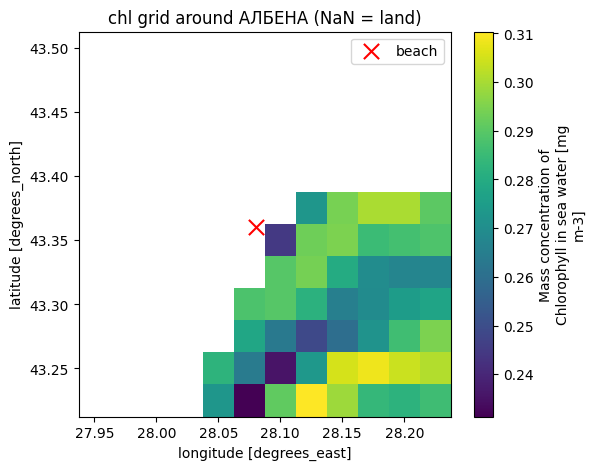

In [ ]:
import numpy as np

beach = beaches.iloc[5]   # Албена
print(beach['name'], beach['lat'], beach['lon'])

# 1) Look at the local grid — which cells are land (NaN) vs sea?
box = ds_chl['chl'].sel(
    longitude=slice(beach['lon'] - 0.15, beach['lon'] + 0.15),
    latitude=slice(beach['lat'] - 0.15, beach['lat'] + 0.15),
).isel(time=-1, depth=0)

print('grid shape:', box.shape)
print('non-NaN cells in box:', int(np.isfinite(box.values).sum()))

fig, ax = plt.subplots(figsize=(6, 5))
box.plot(ax=ax, cmap='viridis')
ax.scatter(beach['lon'], beach['lat'], c='red', marker='x', s=120, label='beach')
ax.legend(); ax.set_title(f"chl grid around {beach['name']} (NaN = land)")
plt.show()

snapped to: (43.349998474121094, 28.100000381469727) | original: (np.float64(43.36), np.float64(28.0803))
count    31.000000
mean      1.350890
std       0.791841
min       0.244554
25%       0.712128
50%       1.397776
75%       1.873378
max       3.180812
Name: chl, dtype: float64


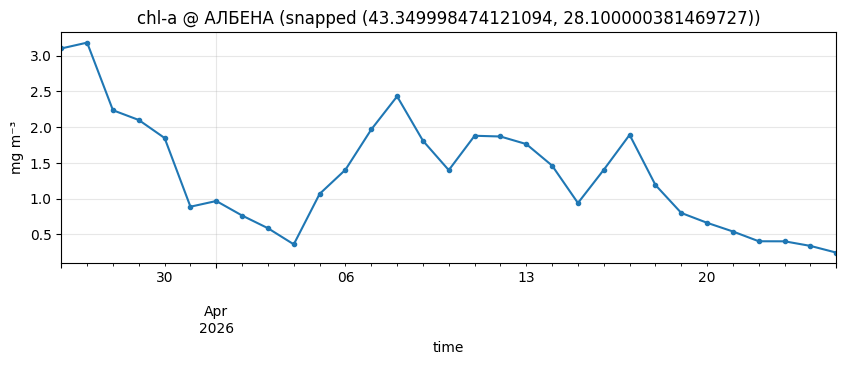

In [ ]:
def nearest_sea_series(ds, var, lat, lon, search_deg=0.2):
    """Snap to the closest non-NaN grid cell by spiraling outward."""
    da = ds[var]
    if 'depth' in da.dims:
        da = da.isel(depth=0)

    box = da.sel(
        longitude=slice(lon - search_deg, lon + search_deg),
        latitude=slice(lat - search_deg, lat + search_deg),
    )

    # Mask: any time step has a value
    sea_mask = np.isfinite(box.values).any(axis=box.dims.index('time'))
    sea_mask = xr.DataArray(sea_mask, dims=[d for d in box.dims if d != 'time'])
    if not bool(sea_mask.any()):
        return None, None

    # Distance from beach to every sea cell
    lon2d, lat2d = np.meshgrid(box['longitude'], box['latitude'])
    dist = np.sqrt((lon2d - lon) ** 2 + (lat2d - lat) ** 2)
    dist = np.where(sea_mask.values, dist, np.inf)

    iy, ix = np.unravel_index(np.argmin(dist), dist.shape)
    snap_lat = float(box['latitude'].values[iy])
    snap_lon = float(box['longitude'].values[ix])
    series = box.sel(latitude=snap_lat, longitude=snap_lon).to_pandas()
    return series, (snap_lat, snap_lon)

series, snapped = nearest_sea_series(ds_chl, 'chl', beach['lat'], beach['lon'])
print('snapped to:', snapped, '| original:', (beach['lat'], beach['lon']))
print(series.describe())

fig, ax = plt.subplots(figsize=(10, 3))
series.plot(ax=ax, marker='o', ms=3)
ax.set_title(f"chl-a @ {beach['name']} (snapped {snapped})")
ax.set_ylabel('mg m⁻³'); ax.grid(alpha=0.3)
plt.show()

## Step 5 — Repeat for oxygen, nutrients, temperature

In [31]:
# Auto-discover the PHY temperature dataset id (prefer 2.5km daily to match BGC grid)
phy_info = cm.describe(product_id='BLKSEA_ANALYSISFORECAST_PHY_007_001')
phy_ids = [d.dataset_id for p in phy_info.products for d in p.datasets]
DS_PHY_TEM = next(
    (i for i in phy_ids if 'phy-tem' in i and '2.5km' in i and 'P1D' in i),
    next((i for i in phy_ids if 'temp' in i and '2.5km' in i and 'P1D' in i), None),
)
print('using temp dataset:', DS_PHY_TEM)

DS_O2 = 'cmems_mod_blk_bgc-pp-o2_anfc_2.5km_P1D-m'

common_kw = dict(
    minimum_longitude=BG_BBOX['min_lon'], maximum_longitude=BG_BBOX['max_lon'],
    minimum_latitude=BG_BBOX['min_lat'],  maximum_latitude=BG_BBOX['max_lat'],
    start_datetime=str(start), end_datetime=str(end),
    minimum_depth=0.3, maximum_depth=1.5,   # surface-ish, avoids the < 0.25 warning
)

ds_o2  = cm.open_dataset(dataset_id=DS_O2,      variables=['o2', 'o2b'], **common_kw)
ds_nut = cm.open_dataset(dataset_id=DS_NUT,     variables=['no3', 'po4'], **common_kw)
ds_tem = cm.open_dataset(dataset_id=DS_PHY_TEM, variables=['thetao'],     **common_kw)
temp_var = 'thetao'

for name, d in [('o2', ds_o2), ('nut', ds_nut), ('tem', ds_tem)]:
    print(name, list(d.data_vars), '|', dict(d.dims))

Fetching catalogue 1: 100%|██████████| 2/2 [00:07<00:00,  3.87s/it]


using temp dataset: cmems_mod_blk_phy-temp_anfc_2.5km_P1D-m


INFO - 2026-04-25T15:23:59Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-04-25T15:23:59Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-04-25T15:23:59Z - The dataset cmems_mod_blk_bgc-pp-o2_anfc_2.5km_P1D-m, version '202511', part 'default' is currently being updated. Data after 2026-04-24T00:00:00.000Z may not be up to date.
INFO - 2026-04-25T15:24:03Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-04-25T15:24:03Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-04-25T15:24:03Z - The dataset cmems_mod_blk_bgc-nut_anfc_2.5km_P1D-m, version '202511', part 'default' is currently being updated. Data after 2026-04-24T00:00:00.000Z may not be up to date.
INFO - 2026-04-25T15:24:07Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset vers

o2 [np.str_('o2'), np.str_('o2b')] | {'depth': 2, 'latitude': 73, 'longitude': 48, 'time': 31}
nut [np.str_('no3'), np.str_('po4')] | {'depth': 2, 'latitude': 73, 'longitude': 48, 'time': 31}
tem [np.str_('thetao')] | {'depth': 1, 'latitude': 73, 'longitude': 48, 'time': 31}


/tmp/ipykernel_3208/2970176802.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(name, list(d.data_vars), '|', dict(d.dims))


In [33]:
def point_series(ds, var, lat, lon):
    """Snap to nearest sea cell, return a 1D time series."""
    s, _ = nearest_sea_series(ds, var, lat, lon)
    return s

lat, lon = beach['lat'], beach['lon']
df_one = pd.DataFrame({
    'chl':    point_series(ds_chl, 'chl',    lat, lon),
    'o2':     point_series(ds_o2,  'o2',     lat, lon),
    'o2b':    point_series(ds_o2,  'o2b',    lat, lon),
    'no3':    point_series(ds_nut, 'no3',    lat, lon),
    'po4':    point_series(ds_nut, 'po4',    lat, lon),
    'thetao': point_series(ds_tem, 'thetao', lat, lon),
})
df_one.tail(10)

,chl,o2,o2b,no3,po4,thetao
time,,,,,,
2026-04-16,1.403135,340.470581,None,4.563890,0.000394,10.599240
2026-04-17,1.891485,337.100647,None,4.391977,0.000239,11.117063
2026-04-18,1.190097,330.429901,None,4.149708,0.000277,11.265310
2026-04-19,0.799202,324.816132,None,4.040133,0.000371,11.740789
2026-04-20,0.661316,324.810120,None,3.910826,0.000448,11.937492
2026-04-21,0.539878,327.326996,None,3.442842,0.000554,11.758164
2026-04-22,0.403372,319.176178,None,3.391076,0.000706,11.750889
2026-04-23,0.402624,322.541473,None,3.257509,0.000695,11.747611
2026-04-24,0.338409,323.991699,None,2.886486,0.000750,11.958750


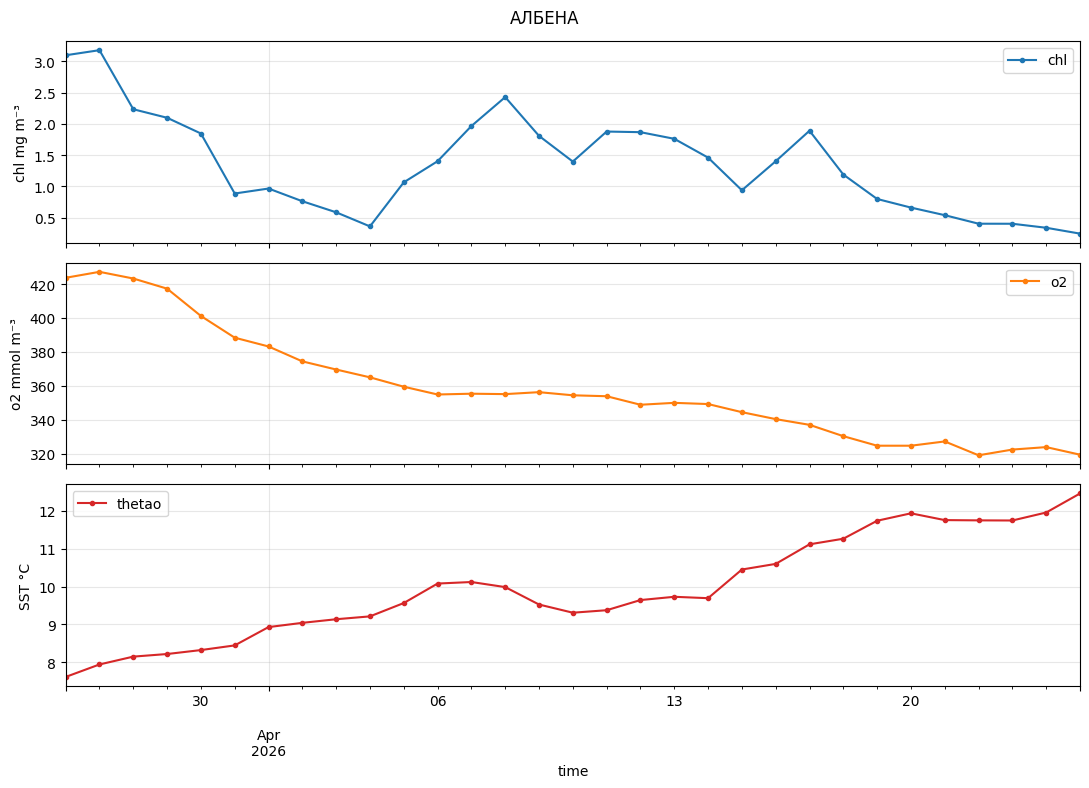

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
df_one[['chl']].plot(ax=axes[0], marker='o', ms=3); axes[0].set_ylabel('chl mg m⁻³')
df_one[['o2']].plot(ax=axes[1], marker='o', ms=3, color='C1'); axes[1].set_ylabel('o2 mmol m⁻³')
df_one[['thetao']].plot(ax=axes[2], marker='o', ms=3, color='C3'); axes[2].set_ylabel('SST °C')
for ax in axes: ax.grid(alpha=0.3)
fig.suptitle(beach['name'])
plt.tight_layout(); plt.show()

## Step 6 — Scoring rules

Simple traffic-light. Tune thresholds as needed.

In [36]:
def score(row):
    flags = []
    if row['chl_mean'] > 5:           flags.append(('chl', 'red'))
    elif row['chl_mean'] > 2:         flags.append(('chl', 'amber'))
    else:                             flags.append(('chl', 'green'))

    if row['o2_min'] < 100:           flags.append(('o2', 'red'))
    elif row['o2_min'] < 250:         flags.append(('o2', 'amber'))
    else:                             flags.append(('o2', 'green'))

    if row['sst_max'] > 28:           flags.append(('sst', 'red'))
    elif row['sst_max'] > 26:         flags.append(('sst', 'amber'))
    else:                             flags.append(('sst', 'green'))

    worst = 'red' if any(c=='red' for _,c in flags) else 'amber' if any(c=='amber' for _,c in flags) else 'green'
    return pd.Series({**{f'flag_{k}': v for k,v in flags}, 'overall': worst})

## Step 7 — Loop over ALL beaches, build summary table

Datasets are already loaded for the BG bbox — `.sel(method='nearest')` just slices in memory.  
On a fresh kernel this takes ~30s for 92 beaches over 30 days.

In [37]:
rows = []
for _, b in beaches.iterrows():
    chl, snap_chl = nearest_sea_series(ds_chl, 'chl',    b['lat'], b['lon'])
    o2,  _        = nearest_sea_series(ds_o2,  'o2',     b['lat'], b['lon'])
    o2b, _        = nearest_sea_series(ds_o2,  'o2b',    b['lat'], b['lon'])
    sst, _        = nearest_sea_series(ds_tem, temp_var, b['lat'], b['lon'])
    no3, _        = nearest_sea_series(ds_nut, 'no3',    b['lat'], b['lon'])
    po4, _        = nearest_sea_series(ds_nut, 'po4',    b['lat'], b['lon'])

    if chl is None or snap_chl is None:
        rows.append({'id': b['id'], 'name': b['name'], 'error': 'all-land'})
        continue

    snap_km = 111 * np.hypot(snap_chl[0] - b['lat'], snap_chl[1] - b['lon'])
    rows.append({
        'id': b['id'], 'name': b['name'],
        'lat': b['lat'], 'lon': b['lon'],
        'snap_km':     round(snap_km, 2),
        'eea_quality': b['eea_quality'],
        'chl_mean':    float(chl.mean()),
        'chl_max':     float(chl.max()),
        'o2_mean':     float(o2.mean())  if o2  is not None else None,
        'o2b_min':     float(o2b.min())  if o2b is not None else None,   # hypoxia at bottom
        'sst_mean':    float(sst.mean()) if sst is not None else None,
        'sst_max':     float(sst.max()) if sst is not None else None,
        'no3_mean':    float(no3.mean()) if no3 is not None else None,
        'po4_mean':    float(po4.mean()) if po4 is not None else None,
        'n_days':      int(np.isfinite(chl.values).sum()),
    })

summary = pd.DataFrame(rows)

# Re-score using bottom O2 instead of surface
def score(row):
    if 'error' in row and pd.notna(row.get('error')):
        return pd.Series({'flag_chl': None, 'flag_o2': None, 'flag_sst': None, 'overall': 'unknown'})
    flags = {}
    flags['flag_chl'] = 'red'   if row['chl_mean'] > 5   else 'amber' if row['chl_mean'] > 2   else 'green'
    flags['flag_o2']  = 'red'   if (row['o2b_min'] or 999) < 100 else 'amber' if (row['o2b_min'] or 999) < 250 else 'green'
    flags['flag_sst'] = 'red'   if (row['sst_max'] or 0)   > 28  else 'amber' if (row['sst_max'] or 0)   > 26  else 'green'
    worst = 'red' if 'red' in flags.values() else 'amber' if 'amber' in flags.values() else 'green'
    flags['overall'] = worst
    return pd.Series(flags)

summary = summary.join(summary.apply(score, axis=1))
summary.head(10)

,id,name,lat,lon,snap_km,eea_quality,chl_mean,chl_max,o2_mean,o2b_min,sst_mean,sst_max,no3_mean,po4_mean,n_days,flag_chl,flag_o2,flag_sst,overall
0,BG3310104426003018,КАМЧИЯ-ПЛАЖ РОМАНТИКА,43.0392,27.8889,2.00,Excellent,1.518809,7.340933,361.298676,NaN,9.939205,12.258277,4.946770,0.000582,31,green,green,green,green
1,BG3310507598003022,БЯЛА-ПЛАЖ ЧАЙКА,42.8542,27.8981,3.02,Excellent,1.663355,6.179174,366.970276,NaN,9.839740,12.288806,4.257430,0.000518,31,green,green,green,green
2,BG3310610135003006,СВ.СВ. КОНСТАНТИН И ЕЛЕНА-ГОЛЯМ ПЛАЖ,43.2325,28.0153,3.76,Excellent,1.668137,6.448420,362.470673,NaN,9.905738,12.493627,5.467961,0.000451,31,green,green,green,green
3,BG3310610135003016,ХИЖА ЧЕРНОМОРЕЦ,43.1186,27.9286,2.48,Excellent,1.737445,6.823749,361.044037,NaN,9.858300,12.391031,5.336092,0.000410,31,green,green,green,green
4,BG3320302508008016,БАЛЧИК-ДВОРЕЦА,43.4028,28.1464,3.11,Excellent,1.524357,4.568818,363.623749,NaN,9.940919,12.325992,5.717581,0.000406,31,green,green,green,green
5,BG3320353120008019,АЛБЕНА,43.3600,28.0803,2.45,Excellent,1.350890,3.180812,358.911224,NaN,9.960924,12.461907,5.691302,0.000429,31,green,green,green,green
6,BG3321707257008007,БОЛАТА,43.3825,28.4706,3.37,Excellent,2.239899,11.930892,378.995270,NaN,9.963879,12.363725,2.898303,0.004980,31,amber,green,green,amber
7,BG3320302508008012,ТУЗЛАТА,43.3997,28.2250,2.74,Good,1.549901,6.341731,362.223022,NaN,9.968534,12.410154,5.510438,0.000424,31,green,green,green,green
8,BG3410407079002018,БУРГАС-ПЛАЖ ЧЕРНОМОРСКИ СОЛНИЦИ,42.5144,27.4861,1.94,Excellent,1.312526,2.556675,347.429291,NaN,10.041052,12.649327,2.472548,0.003942,31,green,green,green,green
9,BG3411344094002037,ЛОЗЕНЕЦ-ЦЕНТРАЛЕН ПЛАЖ,42.2125,27.8056,2.56,Excellent,0.895437,2.915235,359.084717,NaN,10.071395,12.811021,2.106302,0.000669,31,green,green,green,green


In [38]:
# distribution of overall flag
print(summary['overall'].value_counts())
print('\nworst chl beaches:')
print(summary.nlargest(10, 'chl_mean')[['name','chl_mean','sst_mean','overall','eea_quality']])

overall
green    85
amber     7
Name: count, dtype: int64

worst chl beaches:
                          name  chl_mean  sst_mean overall eea_quality
44                КРАПЕЦ-СЕВЕР  3.377892  9.909472   amber   Excellent
43          ДУРАНКУЛАК-СЕВЕР 2  3.364354  9.889641   amber        Good
74          ДУРАНКУЛАК-СЕВЕР 1  3.335519  9.881665   amber   Excellent
60            КЪМПИНГ ДОБРУДЖА  3.197258  9.958368   amber   Excellent
19      РУСАЛКА-ЦЕНТРАЛЕН ПЛАЖ  2.367398  9.919749   amber   Excellent
42          РУСАЛКА-ГОЛЯМ ПЛАЖ  2.367398  9.919749   amber   Excellent
6                       БОЛАТА  2.239899  9.963879   amber   Excellent
72                   ПАША ДЕРЕ  1.839251  9.831490   green   Excellent
81  ШКОРПИЛОВЦИ-ЦЕНТРАЛЕН ПЛАЖ  1.751277  9.823398   green   Excellent
3              ХИЖА ЧЕРНОМОРЕЦ  1.737445  9.858300   green   Excellent


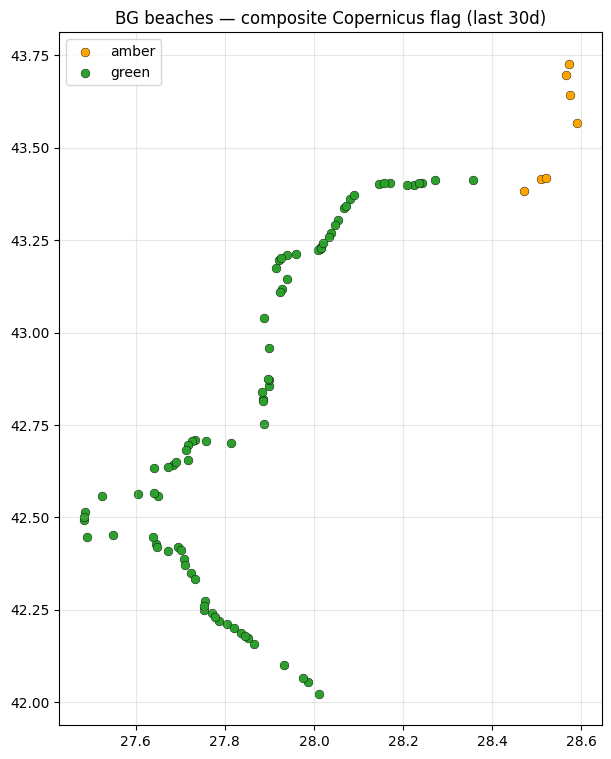

In [39]:
# Map coloured by overall flag
color_map = {'green': 'tab:green', 'amber': 'orange', 'red': 'tab:red'}
fig, ax = plt.subplots(figsize=(7, 9))
for flag, sub in summary.dropna(subset=['overall']).groupby('overall'):
    ax.scatter(sub['lon'], sub['lat'], c=color_map[flag], label=flag, s=40, edgecolor='k', linewidth=0.3)
ax.legend(); ax.set_title('BG beaches — composite Copernicus flag (last 30d)')
ax.grid(alpha=0.3); plt.show()

In [40]:
# Save for downstream use
summary.to_csv('bg_beaches_water_quality.csv', index=False)
print('wrote bg_beaches_water_quality.csv', summary.shape)

wrote bg_beaches_water_quality.csv (92, 19)


In [41]:
!pip install folium branca

/tmp/ipykernel_3208/4238469340.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('YlGnBu')



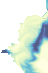

In [42]:
import folium
from folium.raster_layers import ImageOverlay
from branca.colormap import linear
from matplotlib import cm as mcm
from matplotlib.colors import Normalize
import io, base64
from PIL import Image

# 1) Take the latest chl slice (lat x lon), surface depth
chl_grid = ds_chl['chl'].isel(time=-1)
if 'depth' in chl_grid.dims:
    chl_grid = chl_grid.isel(depth=0)
chl_grid = chl_grid.transpose('latitude', 'longitude')
arr = chl_grid.values

# 2) Build a coloured RGBA PNG with NaN -> transparent
vmin, vmax = np.nanpercentile(arr, [5, 95])
norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
cmap = mcm.get_cmap('YlGnBu')
rgba = cmap(norm(arr))
rgba[..., 3] = np.where(np.isfinite(arr), 0.7, 0.0)   # alpha channel

# Flip vertically so north-up matches folium
img = (rgba[::-1] * 255).astype(np.uint8)
buf = io.BytesIO()
Image.fromarray(img).save(buf, format='PNG')
data_url = 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode()

# 3) Bounds: [[south, west], [north, east]]
lats = chl_grid['latitude'].values
lons = chl_grid['longitude'].values
bounds = [[float(lats.min()), float(lons.min())],
          [float(lats.max()), float(lons.max())]]

# 4) Folium map with satellite basemap
m = folium.Map(
    location=[float(beaches['lat'].mean()), float(beaches['lon'].mean())],
    zoom_start=8,
    tiles=None,
)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Satellite',
    overlay=False,
    control=True,
).add_to(m)

# Chl-a heatmap overlay
ImageOverlay(
    image=data_url,
    bounds=bounds,
    opacity=0.75,
    name=f'Chl-a {pd.Timestamp(chl_grid["time"].values).date()} (mg m⁻³)',
).add_to(m)

# Colour bar legend
colormap = linear.YlGnBu_09.scale(vmin, vmax)
colormap.caption = 'Chlorophyll-a (mg m⁻³)'
colormap.add_to(m)

# 5) Beach markers coloured by overall flag
flag_color = {'green': 'green', 'amber': 'orange', 'red': 'red', 'unknown': 'gray'}
for _, b in summary.iterrows():
    flag = b.get('overall', 'unknown') or 'unknown'
    popup = (
        f"<b>{b['name']}</b><br>"
        f"EEA: {b.get('eea_quality')}<br>"
        f"Chl mean: {b.get('chl_mean'):.2f}<br>"
        f"O₂b min: {b.get('o2b_min')}<br>"
        f"SST max: {b.get('sst_max')}<br>"
        f"Overall: <b>{flag}</b>"
    ) if pd.notna(b.get('chl_mean')) else f"<b>{b['name']}</b><br>{b.get('error','no data')}"
    folium.CircleMarker(
        location=[b['lat'], b['lon']],
        radius=5,
        color=flag_color.get(flag, 'gray'),
        fill=True, fill_opacity=0.9,
        popup=folium.Popup(popup, max_width=260),
    ).add_to(m)

folium.LayerControl().add_to(m)
m

## Debugging notes

- **`cm.open_dataset` hangs / 401**: run `copernicusmarine login` in a terminal first, or pass `username=` / `password=` kwargs.
- **Dataset id not found**: re-run Step 2 — Copernicus renames products occasionally. Update the `DS_*` constants from the `describe()` output.
- **All NaN at a beach**: the nearest grid cell is probably on land. Bulgarian coast hugs cliffs in places; nudge `lon` ~0.02° east before `.sel`, or use `xarray`'s `.sel` with a small window and `.mean()` over sea-only cells.
- **Variable not in dataset**: check `list(ds.data_vars)` — chl might live in PFT, oxygen in BIO, etc. The Copernicus product page lists which variable lives in which sub-dataset.
- **Slow loop**: pre-load each xarray into memory with `ds.load()` after slicing the bbox — then per-beach `.sel` is instant.
